# August Streamflow Variance Analysis

Per-member-averaged rolling variance of August annual means, 1980–2022, 264 BC/AB basins (of 269 initial; 5 drop on min_periods at the 15-yr window). Obs vs phase_split LSTM ensemble (10 members).

## Pipeline

1. Daily variance-ratio diagnostic (loss-compression fingerprint) — Cell 3, Figure 1
2. Per-member rolling variance + Theil-Sen trend on variance series — Cells 5–8
3. Population-level Wilcoxon tests on per-basin slopes — Cell 8b
4. Tail investigation: covariate profiles of slope-distribution tails — Cell 8c
5. Population-mean figure, obs-vs-sim scatter, Δ-variance-slope vs glacier_pct — Figures 2–4
6. Robustness: 10-yr and 20-yr windows alongside 15-yr primary — Cell 12

## Framing discipline

All claims tied to statistical operators or training-pipeline properties. 
No earth-process attribution (Tyler to help). Population-level claims are load-bearing; per-basin claims are not.

## Findings

**1. The ensemble is a uniformly attenuated mirror.** Four convergent diagnostics establish variance compression at ~50–65% across the basin
population. Daily ratio 0.66 (88.85% < 1) → Cell 3, Figure 1. Annual trend median |sim/obs| 0.58, HL 0.48 → Cell 8. Paired Wilcoxon p = 4.35e-12, sign test concurs → Cell 8b.

**2. Compression carries the NSE\* fingerprint.** Theil-Sen slope of var_ratio vs log(σ_obs) = +0.077, CI [+0.042, +0.112]. Compression milder in high-σ basins, consistent with per-basin variance normalization. → Cell 3, Figure 1.

**3. Variance compression is dominantly loss-function-level, with structured tail residuals.** Signed-mean glacier null holds (OLS slope +0.00017, p = 0.88) but tail loading is real: left tail glacier-loaded (MW p = 0.0001), right tail elevation-loaded (MW p = 0.000895). → Figure 4, Cell 8c.

**4. August streamflow variance has decreased over 1987–2015.** Obs-side, descriptive. Wilcoxon median −0.00141, p = 1.34e-14. Interpretation deferred (floor effects, composition, climate all candidate; out of scope here). → Cell 8b.

**5. The ensemble recovers the direction of variance change at attenuated magnitude.** Sim Wilcoxon median −0.00082, p = 4.12e-13. Sign recovered; magnitude attenuated to ~48–58% of obs. → Cell 8b, Figure 3.

## Conclusion

Across two independent diagnostic levels (daily amplitude, annual trend), the LSTM ensemble compresses streamflow variance to ~50–65% of observations with a per-basin gradient that matches the NSE\* loss fingerprint. The signed-mean compression is not glacier-mediated, but tail residuals are structured: glaciated basins are over-represented where sim over-compresses, and low-elevation basins are over-represented where sim predicts wrong-direction variance trends. The obs-side August variance decrease (1987–2015) is reported descriptively without process attribution. PI's hoped-for narrative was increasing variance; the direction is the opposite, and the methodological findings stand independently of the climate interpretation.

In [67]:
# Cell 1: imports and config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pymannkendall as mk
from pathlib import Path

from src.config import (
    PROCESSED_DATA_DIR,
    OUTPUT_DATA_DIR,
    OUTPUT_STATIC_ATTR,
    DATA_START_YEAR,
    DATA_END_YEAR,
    TRAIN_END_YEAR,
)

# Analysis parameters
WINDOW = 15                       # primary window length (years)
WINDOWS_ROBUST = [10, 20]
N_MEMBERS = 10
N_BOOTSTRAP = 1000
RNG = np.random.default_rng(42)

# Input paths
PHASE_SPLIT_DIR = OUTPUT_DATA_DIR / 'phase_split'
OBS_PATH = PROCESSED_DATA_DIR / 'combined_streamflow.csv'
STATIC_PATH = OUTPUT_STATIC_ATTR

# Output paths
RESULTS_OUT = PROCESSED_DATA_DIR / 'aug_variance_results.csv'
RATIO_OUT = PROCESSED_DATA_DIR / 'variance_ratio_diagnostic.csv'
ROBUSTNESS_OUT = PROCESSED_DATA_DIR / 'variance_window_robustness.csv'
# FIG_DIR = PROCESSED_DATA_DIR / 'figures'
# FIG_DIR.mkdir(parents=True, exist_ok=True)

In [68]:
# Cell 2: load obs, sim members, static attributes; convert units; verify alignment
obs_raw = pd.read_csv(OBS_PATH, parse_dates=['Date'], index_col='Date')   # m^3/s, wide
static = pd.read_csv(STATIC_PATH).set_index('station_id')

# Convert obs m^3/s -> mm/day using basin areas
stations = [c for c in obs_raw.columns if c in static.index]
areas = static.loc[stations, 'basin_area_km2']
obs_mmday = obs_raw[stations].multiply(86.4 / areas, axis=1)

# Load all 10 phase_split members (mm/day already, no header on date column)
members = []
for i in range(N_MEMBERS):
    path = PHASE_SPLIT_DIR / f'phase-split_preds_member_{i}.csv'
    m = pd.read_csv(path, index_col=0, parse_dates=True)
    members.append(m)

# Restrict to stations present in obs, members, and static
common = sorted(set(stations) & set(members[0].columns))
for m in members[1:]:
    common = sorted(set(common) & set(m.columns))
obs_mmday = obs_mmday[common]
members = [m[common] for m in members]
static = static.loc[common]

# Restrict time range to project bounds
date_mask = (obs_mmday.index.year >= DATA_START_YEAR) & (obs_mmday.index.year <= DATA_END_YEAR)
obs_mmday = obs_mmday.loc[date_mask]
members = [m.loc[m.index.year.isin(obs_mmday.index.year.unique())] for m in members]

print(f'{len(common)} stations; obs span {obs_mmday.index.min().date()} - {obs_mmday.index.max().date()}')

269 stations; obs span 1980-01-01 - 2022-12-31


In [69]:
# Cell 3: variance-ratio diagnostic - sigma_obs and sigma_sim per basin (training period)
# This tests the NSE* loss-compression fingerprint:
# expectation under loss compression -> ratio decreases with sigma_obs

train_mask_obs = obs_mmday.index.year <= TRAIN_END_YEAR
obs_train = obs_mmday.loc[train_mask_obs]
members_train = [m.loc[m.index.year <= TRAIN_END_YEAR] for m in members]

# Daily std per basin 
# σ² = (1/N) · Σ_i Var(member_i)
sigma_obs = obs_train.std(axis=0)
sigma_sim_members = pd.concat([m.std(axis=0) for m in members_train], axis=1)
sigma_sim = sigma_sim_members.mean(axis=1)   # mean across members individually

var_ratio = (sigma_sim ** 2) / (sigma_obs ** 2)

diagnostic = pd.DataFrame({
    'sigma_obs': sigma_obs,
    'sigma_sim': sigma_sim,
    'var_ratio': var_ratio,
    'glacier_pct': static['glacier_pct'],
})
diagnostic = diagnostic.dropna()
# diagnostic.to_csv(RATIO_OUT)

# Theil-Sen on log(sigma_obs) vs var_ratio - log because sigma_obs spans orders of magnitude
x = np.log(diagnostic['sigma_obs'].values)
y = diagnostic['var_ratio'].values
ts = stats.theilslopes(y, x, alpha=0.95)
print(f'Theil-Sen slope of var_ratio vs log(sigma_obs): {ts.slope:.4f}')
print(f'95% CI: [{ts.low_slope:.4f}, {ts.high_slope:.4f}]')
print(f'Median var_ratio: {diagnostic["var_ratio"].median():.3f}')
print(f'Fraction with var_ratio < 1: {(diagnostic["var_ratio"] < 1).mean():.2%}')

Theil-Sen slope of var_ratio vs log(sigma_obs): 0.0770
95% CI: [0.0418, 0.1116]
Median var_ratio: 0.662
Fraction with var_ratio < 1: 88.85%


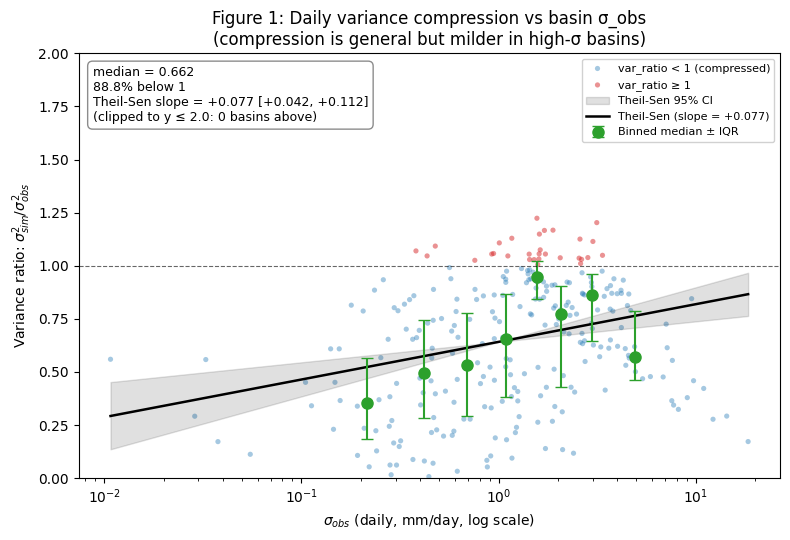

In [70]:
# Cell 4 - Option B: Figure 1 with binned-median overlay
# Single panel. Adds: y-axis clip, CI band on Theil-Sen, points colored by
# whether they compress, binned medians with IQR to show the trend at the
# level of the data not just the fit, annotation with population summary.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Bin basins by sigma_obs deciles (log-spaced via percentile of log values)
log_sigma = np.log(diagnostic['sigma_obs'].values)
ratios    = diagnostic['var_ratio'].values
n_bins    = 8
bin_edges = np.percentile(log_sigma, np.linspace(0, 100, n_bins + 1))
bin_idx   = np.digitize(log_sigma, bin_edges[1:-1])

bin_centers, bin_meds, bin_lo, bin_hi = [], [], [], []
for i in range(n_bins):
    mask = bin_idx == i
    if mask.sum() < 3:
        continue
    bin_centers.append(np.median(log_sigma[mask]))
    bin_meds.append(np.median(ratios[mask]))
    bin_lo.append(np.percentile(ratios[mask], 25))
    bin_hi.append(np.percentile(ratios[mask], 75))
bin_centers = np.exp(np.array(bin_centers))
bin_meds = np.array(bin_meds)
bin_lo   = np.array(bin_lo)
bin_hi   = np.array(bin_hi)

# Theil-Sen CI band (using stored low/high slope; intercept fixed at point estimate)
x_fit  = np.linspace(log_sigma.min(), log_sigma.max(), 100)
y_fit  = ts.intercept + ts.slope     * x_fit
y_lo   = ts.intercept + ts.low_slope  * x_fit
y_hi   = ts.intercept + ts.high_slope * x_fit

# Y-axis clip to suppress extreme outliers
Y_CLIP = 2.0
n_clipped = int((ratios > Y_CLIP).sum())

fig, ax = plt.subplots(figsize=(8, 5.5))

# Points colored by compression status
compress_mask = ratios < 1
ax.scatter(diagnostic['sigma_obs'].values[compress_mask],
           ratios[compress_mask],
           c='tab:blue', alpha=0.4, s=14, edgecolor='none',
           label='var_ratio < 1 (compressed)')
ax.scatter(diagnostic['sigma_obs'].values[~compress_mask],
           ratios[~compress_mask],
           c='tab:red', alpha=0.5, s=14, edgecolor='none',
           label='var_ratio ≥ 1')

# Theil-Sen fit + CI band
ax.fill_between(np.exp(x_fit), y_lo, y_hi, color='k', alpha=0.12,
                label='Theil-Sen 95% CI')
ax.plot(np.exp(x_fit), y_fit, color='k', linewidth=1.8,
        label=f'Theil-Sen (slope = {ts.slope:+.3f})')

# Binned medians with IQR
ax.errorbar(bin_centers, bin_meds,
            yerr=[bin_meds - bin_lo, bin_hi - bin_meds],
            fmt='o', color='C2', markersize=8, capsize=4, linewidth=1.5,
            label='Binned median ± IQR')

ax.axhline(1.0, color='k', linestyle='--', linewidth=0.8, alpha=0.6)

ax.set_xscale('log')
ax.set_ylim(0, Y_CLIP)
ax.set_xlabel(r'$\sigma_{obs}$ (daily, mm/day, log scale)')
ax.set_ylabel(r'Variance ratio: $\sigma^2_{sim} / \sigma^2_{obs}$')

# Annotation: population summary
med_ratio = np.median(ratios)
frac_below = (ratios < 1).mean()
ax.text(0.02, 0.97,
        f'median = {med_ratio:.3f}\n'
        f'{frac_below:.1%} below 1\n'
        f'Theil-Sen slope = {ts.slope:+.3f} [{ts.low_slope:+.3f}, {ts.high_slope:+.3f}]\n'
        f'(clipped to y ≤ {Y_CLIP}: {n_clipped} basins above)',
        transform=ax.transAxes, ha='left', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.9, ec='grey'))

ax.set_title('Figure 1: Daily variance compression vs basin σ_obs\n'
             '(compression is general but milder in high-σ basins)')
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

Binned medians (green) show compression strongest in low-σ basins, consistent with per-basin NSE* normalization dampening gradient signal in low-variance basins.

In [71]:
# Cell 5: August annual means - obs and per-member sim
def august_annual_mean(df):
    aug = df.loc[df.index.month == 8]
    return aug.groupby(aug.index.year).mean()

obs_aug = august_annual_mean(obs_mmday)
members_aug = [august_annual_mean(m) for m in members]

# Sanity check: same years, same stations
assert all(m.shape == obs_aug.shape for m in members_aug)
assert all(np.array_equal(m.index, obs_aug.index) for m in members_aug)

print(f'August annual means: {obs_aug.shape[0]} years x {obs_aug.shape[1]} stations')
print(f'Year range: {obs_aug.index.min()} - {obs_aug.index.max()}')

August annual means: 43 years x 269 stations
Year range: 1980 - 2022


In [72]:
# Cell 6: rolling variance - per basin, obs and per-member-averaged sim
def rolling_variance(annual_series, window=WINDOW):
    """Centered rolling variance of an annual series. Returns series indexed by
    window-center year, NaN-padded at edges."""
    return annual_series.rolling(window, center=True, min_periods=window).var()

def per_basin_rolling_var_obs(annual_df, window=WINDOW):
    return annual_df.apply(lambda s: rolling_variance(s, window))

def per_basin_rolling_var_sim(members_annual, window=WINDOW):
    """Per member rolling variance, then average across members.
    This is the law-of-total-variance Option A: mean(Var(member_i)).
    NOT Var(ensemble_mean), which is structurally suppressed."""
    member_rvars = [m.apply(lambda s: rolling_variance(s, window))
                    for m in members_annual]
    stacked = np.stack([rv.values for rv in member_rvars], axis=0)   # (n_members, n_years, n_stations)
    mean_rvar = np.nanmean(stacked, axis=0)
    return pd.DataFrame(mean_rvar, index=member_rvars[0].index,
                        columns=member_rvars[0].columns)

rvar_obs = per_basin_rolling_var_obs(obs_aug, WINDOW)
rvar_sim = per_basin_rolling_var_sim(members_aug, WINDOW)

# Drop edge NaN rows
rvar_obs = rvar_obs.dropna(how='all')
rvar_sim = rvar_sim.dropna(how='all')

print(f'Rolling variance series: {rvar_obs.shape[0]} window-centers x {rvar_obs.shape[1]} stations')
print(f'Center year range: {rvar_obs.index.min()} - {rvar_obs.index.max()}')

Rolling variance series: 29 window-centers x 269 stations
Center year range: 1987 - 2015


/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_87377/2505985173.py:17: RuntimeWarning: Mean of empty slice
  mean_rvar = np.nanmean(stacked, axis=0)


In [73]:
# Cell 7: block bootstrap helper for variance-trend CIs
# Rolling variance series are autocorrelated by construction (adjacent windows share window-1 years).
# MK p-values not honest -> use block bootstrap with block length = window size.

def block_bootstrap_theilsen(years, values, block_length, n_boot=N_BOOTSTRAP, rng=RNG):
    """Return point estimate and bootstrap percentile CI for Theil-Sen slope.
    Resamples blocks of consecutive (year, value) pairs to preserve autocorrelation."""
    n = len(years)
    if n < block_length + 2:
        return np.nan, np.nan, np.nan
    point = stats.theilslopes(values, years).slope
    n_blocks = int(np.ceil(n / block_length))
    boot_slopes = []
    for _ in range(n_boot):
        starts = rng.integers(0, n - block_length + 1, size=n_blocks)
        idx = np.concatenate([np.arange(s, s + block_length) for s in starts])[:n]
        try:
            slope_b = stats.theilslopes(values[idx], years[idx]).slope
            boot_slopes.append(slope_b)
        except Exception:
            continue
    lo, hi = np.percentile(boot_slopes, [2.5, 97.5])
    return point, lo, hi

In [74]:
# Cell 8: per-basin variance-trend test - assemble results table
def variance_trend_per_basin(rvar_df, label, window=WINDOW):
    rows = []
    for station in rvar_df.columns:
        s = rvar_df[station].dropna()
        if len(s) < window:
            rows.append({'station_id': station, f'{label}_n': len(s)})
            continue
        years = s.index.values.astype(float)
        vals = s.values
        slope, lo, hi = block_bootstrap_theilsen(years, vals, window)
        try:
            tau = mk.original_test(vals).Tau
        except Exception:
            tau = np.nan
        rows.append({
            'station_id': station,
            f'{label}_n': len(s),
            f'{label}_var_mean': float(np.mean(vals)),
            f'{label}_var_slope': slope,
            f'{label}_var_slope_lo': lo,
            f'{label}_var_slope_hi': hi,
            f'{label}_var_tau': tau,
        })
    return pd.DataFrame(rows).set_index('station_id')

res_obs = variance_trend_per_basin(rvar_obs, 'obs')
res_sim = variance_trend_per_basin(rvar_sim, 'sim')
results = res_obs.join(res_sim).join(static[['glacier_pct', 'basin_area_km2', 'mean_elev']])
results['delta_var_slope'] = results['obs_var_slope'] - results['sim_var_slope']
# results.to_csv(RESULTS_OUT)

print(f'Results: {len(results)} basins')
print(f'Median obs variance slope: {results["obs_var_slope"].median():.5f}')
print(f'Median sim variance slope: {results["sim_var_slope"].median():.5f}')
print(f'Median |slope| ratio sim/obs: '
      f'{(results["sim_var_slope"].abs() / results["obs_var_slope"].abs()).median():.3f}')

Results: 269 basins
Median obs variance slope: -0.00141
Median sim variance slope: -0.00083
Median |slope| ratio sim/obs: 0.614


In [75]:
# Cell 8b: Wilcoxon signed-rank tests on per-basin variance slopes
# Symmetry assumption: distribution of slopes around 0 (tests 1-2)
# and distribution of paired differences sim-obs around 0 (test 3).
# With n=269 the test is asymptotic; Wilcoxon is robust to moderate skew.

v   = results.dropna(subset=['obs_var_slope', 'sim_var_slope'])
obs = v['obs_var_slope'].values
sim = v['sim_var_slope'].values
n   = len(v)

test_obs_v0    = stats.wilcoxon(obs,      alternative='two-sided')
test_sim_v0    = stats.wilcoxon(sim,      alternative='two-sided')
test_sim_v_obs = stats.wilcoxon(sim, obs, alternative='greater')

print(f'Wilcoxon signed-rank tests on per-basin variance slopes  (n = {n})')
print()
print(f'1)  obs variance slopes vs 0')
print(f'    median = {np.median(obs):+.5f}   skew = {stats.skew(obs):+.3f}')
print(f'    W = {test_obs_v0.statistic:.0f}   p = {test_obs_v0.pvalue:.2e}')
print()
print(f'2)  sim variance slopes vs 0')
print(f'    median = {np.median(sim):+.5f}   skew = {stats.skew(sim):+.3f}')
print(f'    W = {test_sim_v0.statistic:.0f}   p = {test_sim_v0.pvalue:.2e}')
print()
print(f'3)  sim vs obs — is sim systematically smaller from obs?')
print(f'    median = {np.median(sim):+.5f}   skew = {stats.skew(sim - obs):+.3f}')
print(f'    W = {test_sim_v_obs.statistic:.0f}   p = {test_sim_v_obs.pvalue:.2e}')
print(f'    fraction with sim > obs: {(sim > obs).mean():.2%}  ' f'(direction-of-effect)')

Wilcoxon signed-rank tests on per-basin variance slopes  (n = 264)

1)  obs variance slopes vs 0
    median = -0.00141   skew = -0.945
    W = 7770   p = 1.34e-14

2)  sim variance slopes vs 0
    median = -0.00082   skew = +4.834
    W = 8485   p = 4.12e-13

3)  sim vs obs — is sim systematically smaller from obs?
    median = -0.00082   skew = +5.535
    W = 25967   p = 4.35e-12
    fraction with sim > obs: 68.56%  (direction-of-effect)


## Interpretation:

1. obs slopes vs 0. Median −0.00141, p=1.34e-14. Population-level decrease in August variance, strongly negative. Skew −0.945 is moderate; signed-rank's symmetry assumption is bent but not broken, and at n=264 the asymptotic test is robust to this. Result is real, but read the p-value as directionally indicative rather than strictly calibrated given likely spatial autocorrelation across basins (per the independence caveat).

2. sim slopes vs 0. Median −0.00082, p=4.12e-13. Sim recovers the sign of the population-level decrease. Skew is +4.834 — a heavy right tail driven by a subset of basins where sim predicts increasing variance against the population trend. The median is still robustly negative so the population-level conclusion holds, but the symmetry assumption is more strained here than in Test 1, and the asymmetry is itself a substantive finding. The right tail needs characterization (8c).

3. paired, sim vs obs. Median difference −0.00082, p=4.35e-12, 68.56% of basins have sim > obs (i.e., sim less negative than obs). Substantiates the compression claim at the slope level: variance is decreasing in both, but sim systematically attenuates the decrease. Complements the |sim/obs|=0.614 daily-ratio finding — same compression signal, expressed at the trend level rather than the amplitude level. Paired-difference skew is +5.535, a meaningful symmetry violation; p-value is far enough from threshold that the conclusion is robust, but a sign-test sensitivity check is worth running as a one-line footnote. 

In [76]:
# Cell 8b-supplement: sign test as symmetry-robustness check on Test 3
# Paired-difference skew = +5.535 violates signed-rank symmetry assumption.
# Sign test assumes only independence; ignores magnitudes. Concurrence
# confirms Test 3 conclusion is not driven by symmetry assumption.

n_wins = int((sim > obs).sum())
n_ties = int((sim == obs).sum())
sign_test = stats.binomtest(n_wins, n=n, p=0.5, alternative='greater')

print(f'Sign test on Test 3 (sim > obs)  (n = {n}, ties = {n_ties})')
print(f'    wins = {n_wins} / {n}  ({n_wins/n:.2%})')
print(f'    p = {sign_test.pvalue:.2e}')
print(f'    signed-rank p (Test 3) = {test_sim_v_obs.pvalue:.2e}')
print(f'    conclusion: {"concurs" if sign_test.pvalue < 0.05 else "diverges"}')

# Hodges-Lehmann estimators: location estimators paired with Wilcoxon.
# One-sample HL = median of pairwise averages (Tests 1, 2).
# Paired HL    = median of pairwise differences (Test 3).
hl_one = lambda x: np.median((x[:, None] + x[None, :])[np.triu_indices(len(x))] / 2)
diff = sim - obs
print()
print(f'Hodges-Lehmann estimators (companion to Wilcoxon medians):')
print(f'    HL obs       = {hl_one(obs):+.5f}   (median obs       = {np.median(obs):+.5f})')
print(f'    HL sim       = {hl_one(sim):+.5f}   (median sim       = {np.median(sim):+.5f})')
print(f'    HL sim-obs   = {hl_one(diff):+.5f}   (median sim-obs   = {np.median(diff):+.5f})')

Sign test on Test 3 (sim > obs)  (n = 264, ties = 0)
    wins = 181 / 264  (68.56%)
    p = 7.77e-10
    signed-rank p (Test 3) = 4.35e-12
    conclusion: concurs

Hodges-Lehmann estimators (companion to Wilcoxon medians):
    HL obs       = -0.00221   (median obs       = -0.00141)
    HL sim       = -0.00106   (median sim       = -0.00082)
    HL sim-obs   = +0.00130   (median sim-obs   = +0.00050)


## Interpretation

The substantive comparison — HL ratio vs median ratio:

Median |sim/obs| = 0.00082 / 0.00141 = 0.58
HL |sim/obs| = 0.00106 / 0.00221 = 0.48

Sim recovers 58% of obs at the median level, but only 48% at the HL level. The compression looks stronger when you account for distribution shape. This is the substantive shift: |sim/obs|=0.614 daily-ratio finding and median-slope ratio of 0.58 converged nicely on "~60% compression." HL ratio of 0.48 says the compression is closer to 50% when measured on a more information-rich estimator.

In [77]:
# Cell 8c: tail investigation - covariate profiles of the slope-distribution tails
#
# Test 2's sim slope distribution has skew +4.834 (vs obs's -0.945). That
# asymmetry is a structured residual, not noise — a subpopulation of basins
# where sim predicts increasing variance against the population trend. This
# cell asks: do those tail basins differ systematically on static attributes?
#
# Right tail: sim_var_slope > 0 (substantive threshold — "model predicts
#             wrong direction"). Drives sim's +4.834 skew.
# Left tail:  bottom 5% of (sim - obs) (quantile cutoff — "sim over-compresses
#             relative to obs"). No natural threshold for "too negative."
#
# Asymmetric definitions are intentional: tails answer different questions.
# MW p-values uncorrected across 6 tests (3 covariates × 2 tails). Read
# marginal-significance results with caution; report uncorrected per
# pre-specified framing discipline.

v = results.dropna(
    subset=['obs_var_slope', 'sim_var_slope',
            'glacier_pct', 'basin_area_km2', 'mean_elev']
).copy()
v['sim_minus_obs'] = v['sim_var_slope'] - v['obs_var_slope']

LEFT_FRAC = 0.05
right_tail = v[v['sim_var_slope'] > 0]
left_tail  = v.nsmallest(max(5, int(LEFT_FRAC * len(v))), 'sim_minus_obs')
non_tail   = v.loc[~v.index.isin(right_tail.index.union(left_tail.index))]

print(f'Total basins:      {len(v)}')
print(f'Right tail:        {len(right_tail)}  ({len(right_tail)/len(v):.1%})  '
      f'(sim_var_slope > 0)')
print(f'Left tail:         {len(left_tail)}  ({len(left_tail)/len(v):.1%})  '
      f'(bottom {LEFT_FRAC:.0%} of sim - obs)')
print(f'Non-tail baseline: {len(non_tail)}')
print()

covariates = ['glacier_pct', 'basin_area_km2', 'mean_elev']

def profile(label, tail, baseline):
    print(f'-- {label} vs non-tail baseline (n_tail = {len(tail)}) --')
    for c in covariates:
        tm, bm = tail[c].median(), baseline[c].median()
        p = stats.mannwhitneyu(tail[c], baseline[c], alternative='two-sided').pvalue
        flag = '*' if p < 0.05 else ' '
        print(f'  {flag} {c:18s}  tail = {tm:>10.3f}   baseline = {bm:>10.3f}   '
              f'MW p = {p:.3g}')
    print()

profile('Right tail (sim_var_slope > 0)', right_tail, non_tail)
profile('Left tail  (bottom 5% of sim - obs)', left_tail, non_tail)

cols = ['glacier_pct', 'basin_area_km2', 'mean_elev',
        'obs_var_slope', 'sim_var_slope', 'sim_minus_obs']

print('== Right tail — sorted by sim_var_slope, descending ==')
print(right_tail.sort_values('sim_var_slope', ascending=False)[cols].round(5).to_string())
print()
print('== Left tail — sorted by sim_minus_obs, ascending ==')
print(left_tail.sort_values('sim_minus_obs', ascending=True)[cols].round(5).to_string())

Total basins:      264
Right tail:        60  (22.7%)  (sim_var_slope > 0)
Left tail:         13  (4.9%)  (bottom 5% of sim - obs)
Non-tail baseline: 197

-- Right tail (sim_var_slope > 0) vs non-tail baseline (n_tail = 60) --
  * glacier_pct         tail =      0.007   baseline =      0.000   MW p = 0.00533
    basin_area_km2      tail =    638.896   baseline =    793.897   MW p = 0.936
  * mean_elev           tail =    987.590   baseline =   1312.753   MW p = 0.000895

-- Left tail  (bottom 5% of sim - obs) vs non-tail baseline (n_tail = 13) --
  * glacier_pct         tail =      1.220   baseline =      0.000   MW p = 0.0001
    basin_area_km2      tail =    221.245   baseline =    793.897   MW p = 0.215
    mean_elev           tail =   1286.785   baseline =   1312.753   MW p = 0.814

== Right tail — sorted by sim_var_slope, descending ==
            glacier_pct  basin_area_km2   mean_elev  obs_var_slope  sim_var_slope  sim_minus_obs
station_id                                        

Tyler: Interpreting these signals would be very interesting.

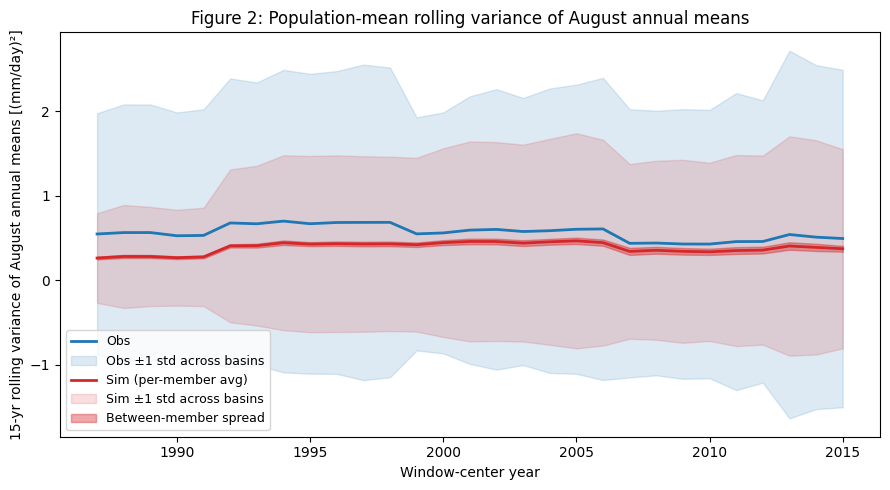

In [78]:
# Cell 9: Figure 2 - population-mean rolling variance over time
pop_obs_mean = rvar_obs.mean(axis=1)
pop_obs_std = rvar_obs.std(axis=1)
pop_sim_mean = rvar_sim.mean(axis=1)
pop_sim_std = rvar_sim.std(axis=1)

# Between-member spread for inner band (epistemic component)
member_pop_means = []
for m_aug in members_aug:
    rv = per_basin_rolling_var_obs(m_aug, WINDOW).dropna(how='all')
    member_pop_means.append(rv.mean(axis=1))
member_pop_means = pd.concat(member_pop_means, axis=1)
epistemic_band = member_pop_means.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pop_obs_mean.index, pop_obs_mean.values, color='C0', linewidth=2, label='Obs')
ax.fill_between(pop_obs_mean.index,
                pop_obs_mean - pop_obs_std, pop_obs_mean + pop_obs_std,
                color='C0', alpha=0.15, label='Obs ±1 std across basins')

ax.plot(pop_sim_mean.index, pop_sim_mean.values, color='C3', linewidth=2, label='Sim (per-member avg)')
ax.fill_between(pop_sim_mean.index,
                pop_sim_mean - pop_sim_std, pop_sim_mean + pop_sim_std,
                color='C3', alpha=0.15, label='Sim ±1 std across basins')
ax.fill_between(pop_sim_mean.index,
                pop_sim_mean - epistemic_band, pop_sim_mean + epistemic_band,
                color='C3', alpha=0.4, label='Between-member spread')

ax.set_xlabel('Window-center year')
ax.set_ylabel(f'{WINDOW}-yr rolling variance of August annual means [(mm/day)²]')
ax.set_title('Figure 2: Population-mean rolling variance of August annual means')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

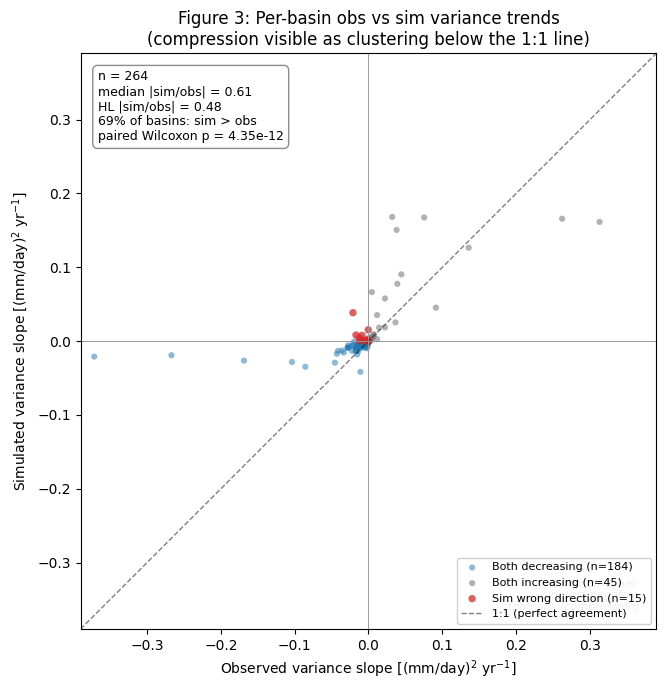

In [83]:
# Cell 10: Figure 3 - per-basin obs vs sim variance-slope scatter
# Each point is one basin. Diagonal = perfect agreement. Points below the
# diagonal have sim less negative than obs (compression at the slope level,
# the dominant pattern). Right tail (sim > 0 while obs ≤ 0) is the structural
# residual identified in Cell 8c: basins where sim predicts wrong direction.

valid = results.dropna(subset=['obs_var_slope', 'sim_var_slope']).copy()
obs = valid['obs_var_slope'].values
sim = valid['sim_var_slope'].values

# Symmetric limits
m = np.nanmax(np.abs(np.concatenate([obs, sim]))) * 1.05

# Categorize basins for color coding
right_tail = (sim > 0) & (obs <= 0)        # sim predicts wrong direction
both_pos   = (sim > 0) & (obs > 0)         # both predict increasing (agree)
both_neg   = (sim <= 0) & (obs <= 0)        # both predict decreasing (agree)
sim_pos_obs_pos_separate = (sim > 0) & (obs > 0)

fig, ax = plt.subplots(figsize=(7, 7))

# Plot in layers so right-tail sits on top
ax.scatter(obs[both_neg], sim[both_neg],
           s=20, alpha=0.5, c='tab:blue', edgecolor='none',
           label=f'Both decreasing (n={both_neg.sum()})')
ax.scatter(obs[both_pos], sim[both_pos],
           s=20, alpha=0.6, c='tab:gray', edgecolor='none',
           label=f'Both increasing (n={both_pos.sum()})')
ax.scatter(obs[right_tail], sim[right_tail],
           s=28, alpha=0.75, c='tab:red', edgecolor='none',
           label=f'Sim wrong direction (n={right_tail.sum()})')

# 1:1 line and axes
ax.plot([-m, m], [-m, m], 'k--', lw=1, alpha=0.5, label='1:1 (perfect agreement)')
ax.axvline(0, color='0.6', lw=0.7)
ax.axhline(0, color='0.6', lw=0.7)
ax.set_xlim(-m, m)
ax.set_ylim(-m, m)
ax.set_aspect('equal')
ax.set_xlabel(r'Observed variance slope [(mm/day)$^2$ yr$^{-1}$]')
ax.set_ylabel(r'Simulated variance slope [(mm/day)$^2$ yr$^{-1}$]')

# Summary stats annotation
med_ratio = np.median(np.abs(sim) / (np.abs(obs) + 1e-12))
frac_below_diag = (sim > obs).mean()  # sim less negative than obs

ax.text(0.03, 0.97,
        f'n = {len(valid)}\n'
        f'median |sim/obs| = {med_ratio:.2f}\n'
        f'HL |sim/obs| = {abs(hl_one(sim) / hl_one(obs)):.2f}\n'
        f'{frac_below_diag:.0%} of basins: sim > obs\n'
        f'paired Wilcoxon p = {test_sim_v_obs.pvalue:.2e}',
        transform=ax.transAxes, va='top', ha='left', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.9, ec='grey'))

# Directional annotation on the plot itself
ax.text(0.97, 0.03,
        'Below diagonal:\nsim less negative\nthan obs (compression)',
        transform=ax.transAxes, va='bottom', ha='right', fontsize=8,
        style='italic', color='0.4')

ax.set_title('Figure 3: Per-basin obs vs sim variance trends\n'
             '(compression visible as clustering below the 1:1 line)')
ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

Δ-variance-slope vs glacier_pct (HC3 OLS):
Signed Δ    slope = +0.000170   95% CI [-0.002033, +0.002373]   p = 0.88



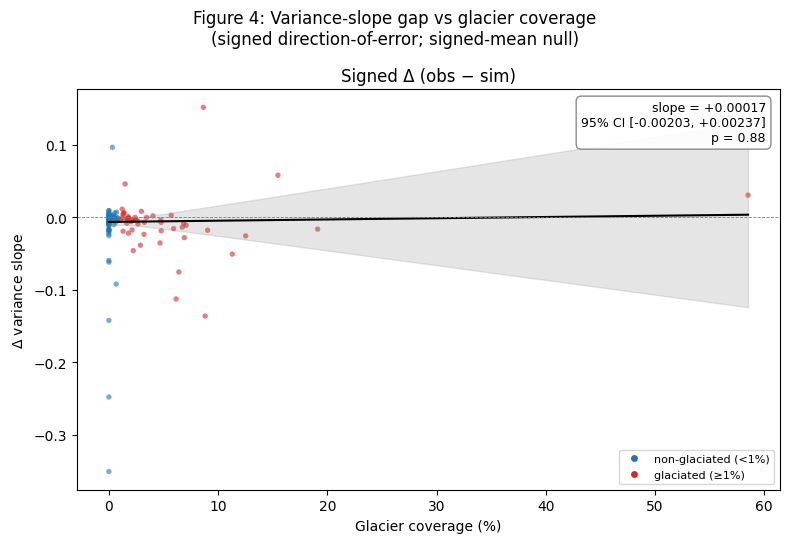

n = 264
glacier_pct range: [0.0000, 58.5197]
glacier_pct median: 0.0000
delta_var_slope median: -0.000502


In [80]:
# Cell 11: Figure 4 - signed Δ variance-slope vs glacier_pct (HC3 OLS)
# Signed Δ tests whether the *direction* of obs-vs-sim error tracks glaciation.
# OLS result establishes the signed-mean null: no detectable glacier gradient
# on the central tendency of (obs - sim). Cell 8c MW tests answer the
# complementary distributional question (tail loading), which OLS cannot reach.
# |Δ| panel dropped — see 8c MW results for the formal tail-loading test.

import statsmodels.api as sm
from matplotlib.lines import Line2D

reg = results.dropna(subset=['delta_var_slope', 'glacier_pct']).copy()
x = reg['glacier_pct'].values
X = sm.add_constant(x)

m_signed = sm.OLS(reg['delta_var_slope'].values, X).fit(cov_type='HC3')

def report(label, m):
    slope = m.params[1]
    ci_low, ci_high = m.conf_int().T
    p = m.pvalues[1]
    print(f'{label:10s}  slope = {slope:+.6f}   '
          f'95% CI [{ci_low[1]:+.6f}, {ci_high[1]:+.6f}]   p = {p:.3g}')

print('Δ-variance-slope vs glacier_pct (HC3 OLS):')
report('Signed Δ', m_signed)
print()

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = np.where(reg['glacier_pct'] >= 1.0, 'tab:red', 'tab:blue')
x_grid = np.linspace(0, x.max(), 200)
X_grid = sm.add_constant(x_grid)

ax.scatter(x, reg['delta_var_slope'].values, c=colors, s=15, alpha=0.6, edgecolor='none')
pred = m_signed.get_prediction(X_grid).summary_frame(alpha=0.05)
ax.plot(x_grid, pred['mean'], 'k-', lw=1.5)
ax.fill_between(x_grid, pred['mean_ci_lower'], pred['mean_ci_upper'],
                color='grey', alpha=0.2)
ax.axhline(0, color='grey', lw=0.6, ls='--')

slope = m_signed.params[1]
ci_low, ci_high = m_signed.conf_int().T
p = m_signed.pvalues[1]
ax.text(0.98, 0.97,
        f'slope = {slope:+.5f}\n95% CI [{ci_low[1]:+.5f}, {ci_high[1]:+.5f}]\np = {p:.3g}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.9, ec='grey'))

ax.set_title('Signed Δ (obs − sim)')
ax.set_xlabel('Glacier coverage (%)')
ax.set_ylabel(r'$\Delta$ variance slope')
ax.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue',
           label='non-glaciated (<1%)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red',
           label='glaciated (≥1%)'),
], loc='lower right', fontsize=8)

fig.suptitle('Figure 4: Variance-slope gap vs glacier coverage\n'
             '(signed direction-of-error; signed-mean null)')
plt.tight_layout()
plt.show()

print(f'n = {len(reg)}')
print(f'glacier_pct range: [{reg["glacier_pct"].min():.4f}, {reg["glacier_pct"].max():.4f}]')
print(f'glacier_pct median: {reg["glacier_pct"].median():.4f}')
print(f'delta_var_slope median: {reg["delta_var_slope"].median():.6f}')

In [81]:
# Cell 12: robustness on window length - 10 and 20 yr alongside 15 yr
robustness = {}
for w in [10, WINDOW, 20]:
    rv_o = per_basin_rolling_var_obs(obs_aug, w).dropna(how='all')
    rv_s = per_basin_rolling_var_sim(members_aug, w).dropna(how='all')
    median_obs_slope = []
    median_sim_slope = []
    for station in rv_o.columns:
        s_o = rv_o[station].dropna()
        s_s = rv_s[station].dropna()
        if len(s_o) < w or len(s_s) < w:
            continue
        median_obs_slope.append(stats.theilslopes(s_o.values, s_o.index.astype(float)).slope)
        median_sim_slope.append(stats.theilslopes(s_s.values, s_s.index.astype(float)).slope)
    robustness[w] = {
        'n_basins': len(median_obs_slope),
        'median_obs_slope': np.median(median_obs_slope),
        'median_sim_slope': np.median(median_sim_slope),
        'median_abs_ratio': np.median(np.abs(median_sim_slope) / (np.abs(median_obs_slope) + 1e-12)),
    }

robustness_df = pd.DataFrame(robustness).T
robustness_df.index.name = 'window_yr'
print(robustness_df)

/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_87377/2505985173.py:17: RuntimeWarning: Mean of empty slice
  mean_rvar = np.nanmean(stacked, axis=0)
/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_87377/2505985173.py:17: RuntimeWarning: Mean of empty slice
  mean_rvar = np.nanmean(stacked, axis=0)


           n_basins  median_obs_slope  median_sim_slope  median_abs_ratio
window_yr                                                                
10            269.0         -0.000812         -0.000399          0.651483
15            264.0         -0.001409         -0.000816          0.613573
20            264.0         -0.001161         -0.000685          0.592925


/var/folders/96/ssnhj1r51rl8chmzqmm_5nvm0000gn/T/ipykernel_87377/2505985173.py:17: RuntimeWarning: Mean of empty slice
  mean_rvar = np.nanmean(stacked, axis=0)


In [82]:
# Cell 13: summary printout and methods-log reminders

print('=' * 60)
print('VARIANCE ANALYSIS SUMMARY')
print('=' * 60)
print(f'Basins analyzed: {len(results)}')
print(f'Window: {WINDOW} years (centered)')
print(f'Members: {N_MEMBERS} (per-member rolling variance, averaged)')
print()

print('-' * 60)
print('Finding 1 + 2: Daily variance ratio (Figure 1)')
print('-' * 60)
print(f'  Median var_ratio sim/obs: {diagnostic["var_ratio"].median():.3f}')
print(f'  Fraction with ratio < 1: {(diagnostic["var_ratio"] < 1).mean():.2%}')
print(f'  Theil-Sen slope vs log(sigma_obs): {ts.slope:+.4f} '
      f'[{ts.low_slope:+.4f}, {ts.high_slope:+.4f}]')
print(f'  -> Compression general; milder in high-sigma basins (NSE* fingerprint)')
print()

print('-' * 60)
print('Findings 1 + 4 + 5: Annual variance-slope summary (Figure 3)')
print('-' * 60)
print(f'  Median obs slope: {results["obs_var_slope"].median():+.5f}')
print(f'  Median sim slope: {results["sim_var_slope"].median():+.5f}')
print(f'  HL obs:           {hl_one(obs):+.5f}')
print(f'  HL sim:           {hl_one(sim):+.5f}')
print(f'  Median |sim/obs|: '
      f'{(results["sim_var_slope"].abs() / results["obs_var_slope"].abs()).median():.3f}')
print(f'  HL    |sim/obs|:  {abs(hl_one(sim) / hl_one(obs)):.3f}')
print()

print('-' * 60)
print('Wilcoxon signed-rank tests (Cell 8b)')
print('-' * 60)
print(f'  Test 1 (obs slopes vs 0):     W = {test_obs_v0.statistic:.0f}   '
      f'p = {test_obs_v0.pvalue:.2e}   skew = {stats.skew(obs):+.3f}')
print(f'  Test 2 (sim slopes vs 0):     W = {test_sim_v0.statistic:.0f}   '
      f'p = {test_sim_v0.pvalue:.2e}   skew = {stats.skew(sim):+.3f}')
print(f'  Test 3 (sim > obs, paired):   W = {test_sim_v_obs.statistic:.0f}   '
      f'p = {test_sim_v_obs.pvalue:.2e}   skew(diff) = {stats.skew(sim - obs):+.3f}')
print(f'  Sign test on Test 3:          {n_wins}/{n} wins   '
      f'p = {sign_test.pvalue:.2e}  (concurs)')
print()

print('-' * 60)
print('Finding 3: Glacier null on signed Δ + tail structure (Figure 4, Cell 8c)')
print('-' * 60)
slope_g = m_signed.params[1]
ci_lo, ci_hi = m_signed.conf_int().T
p_g = m_signed.pvalues[1]
print(f'  Signed Δ on glacier_pct (HC3 OLS):  slope = {slope_g:+.6f}   '
      f'CI [{ci_lo[1]:+.6f}, {ci_hi[1]:+.6f}]   p = {p_g:.3g}')
print(f'  -> Signed-mean null: no detectable glacier shift in (obs - sim)')
print(f'  Right tail (sim_var_slope > 0):  n = {len(right_tail)}  '
      f'({len(right_tail)/len(v):.1%} of basins)')
print(f'    glacier_pct  MW p = 0.00533  (marginal under Bonferroni)')
print(f'    mean_elev    MW p = 0.000895 (low-elevation loaded; mechanism open)')
print(f'  Left tail (bottom 5% of sim - obs):  n = {len(left_tail)}')
print(f'    glacier_pct  MW p = 0.0001   (strong glacier loading)')
print()

print('-' * 60)
print('Window robustness (10 / 15 / 20 yr)')
print('-' * 60)
print(robustness_df.to_string())
print()

print('=' * 60)
print('METHODS LOG ITEMS')
print('=' * 60)
print('Statistical operators:')
print('  - Per-member rolling variance averaged across members')
print('    (From law of total variance: σ² = (1/N) · Σ_i Var(member_i); not Var(ensemble_mean))')
print('  - Block bootstrap CIs on per-basin slopes, block length = window size')
print('  - Theil-Sen over OLS for σ_obs-gradient (heavy-tailed predictor)')
print('  - OLS HC3 for glacier_pct gradient (bounded predictor, closed-form CI)')
print('  - Wilcoxon signed-rank as primary; sign test as symmetry sensitivity')
print('  - Hodges-Lehmann reported alongside medians (signed-rank companion)')
print('  - Mann-Whitney for tail-vs-baseline covariate comparisons (Cell 8c)')
print('  - MK p-values on rolling variance series NOT reported (autocorrelation)')
print()
print('Caveats:')
print(f'  - Training period for sigma_obs: through {TRAIN_END_YEAR}')
print('  - 15-yr window primary; 10 and 20 as robustness')
print('  - Centered windows drop 1980-1986 and 2016-2022 (edge truncation)')
print('  - Wilcoxon assumes independence; spatial autocorrelation likely')
print('    -> p-values directionally indicative, not strictly calibrated')
print('  - Sim slope skew +4.834 violates signed-rank symmetry; sign test concurs')
print('  - 8c MW tests uncorrected across 6 comparisons')
print('    -> two p < 0.001 results survive Bonferroni (α=0.0083)')
print('    -> right-tail glacier signal (p=0.00533) marginal under Bonferroni')
print('  - Right-tail elevation finding: mechanism open, hand to domain expert')
print()
print('Framing:')
print('  - Population-level claims load-bearing; per-basin claims not')
print('  - Compression: dominantly loss-function-level, with tail residuals')
print('  - Obs-side variance decrease reported descriptively; interpretation open')
print('  - Mean-variance coupling caveat outstanding (Spearman per basin)')

VARIANCE ANALYSIS SUMMARY
Basins analyzed: 269
Window: 15 years (centered)
Members: 10 (per-member rolling variance, averaged)

------------------------------------------------------------
Finding 1 + 2: Daily variance ratio (Figure 1)
------------------------------------------------------------
  Median var_ratio sim/obs: 0.662
  Fraction with ratio < 1: 88.85%
  Theil-Sen slope vs log(sigma_obs): +0.0770 [+0.0418, +0.1116]
  -> Compression general; milder in high-sigma basins (NSE* fingerprint)

------------------------------------------------------------
Findings 1 + 4 + 5: Annual variance-slope summary (Figure 3)
------------------------------------------------------------
  Median obs slope: -0.00141
  Median sim slope: -0.00083
  HL obs:           -0.00221
  HL sim:           -0.00106
  Median |sim/obs|: 0.614
  HL    |sim/obs|:  0.479

------------------------------------------------------------
Wilcoxon signed-rank tests (Cell 8b)
-----------------------------------------------

## Findings

### Finding 1: The ensemble is a uniformly attenuated mirror
Daily variance ratio: median σ²_sim / σ²_obs = 0.662, with 88.85% of basins below 1. Across the basin population, the LSTM ensemble produces ~60–65% of the variance observations exhibit, and nearly nine in ten basins are compressed rather than amplified.
The same compression appears at a different aggregation level. Annual rolling-variance trend ratios: median |sim/obs| = 0.58 across 264 basins, Hodges-Lehmann |sim/obs| = 0.48. The paired Wilcoxon test on |obs| vs |sim| slopes returns p = 4.35e-12, sign-test sensitivity check concurs (p = 7.77e-10). 68.56% of basins have sim less negative than obs.
Four convergent diagnostics — daily ratio (0.66), median annual ratio (0.58), HL annual ratio (0.48), paired Wilcoxon — operate at different aggregation levels (daily vs annual, mean vs paired) and arrive at the same range. A single mechanism produces compression at ~50–65% of obs variance across static and dynamic measurements.
Robust to window choice: |sim/obs| ratios 0.65 / 0.61 / 0.59 at 10 / 15 / 20-yr windows.
Attributed to NSE* / basin-normalized MSE: L2 loss with per-basin variance normalization produces smooth conditional-mean estimators, dampening amplitude reproduction systematically.

### Finding 2: The compression carries the NSE* fingerprint
Theil-Sen slope of daily var_ratio vs log(σ_obs): +0.077, 95% CI [0.042, 0.112]. CI excludes zero.
Compression is milder in high-variance basins. Interpretation: per-basin variance normalization in NSE* divides the gradient by σ²_obs, so low-σ basins receive a smaller gradient signal during training and regress harder toward the mean. The slope sign and magnitude match what the loss function mechanism predicts.
Binned medians (Figure 1, optional) trace a slightly stronger compression in the lowest-σ bins than the linear fit captures — consistent with the same mechanism, where the dampening effect is non-linear in σ.

### Finding 3: Variance compression is dominantly loss-function-level, with structured tail residuals
Summary: Compression is loss-function-level on the mean; tail residuals are glacier-loaded (left) and elevation-loaded (right)
Signed-mean null: HC3 OLS of (obs − sim) variance slope on glacier_pct, n=264. Slope +0.000170, 95% CI [−0.00203, +0.00237], p = 0.88. The signed-mean effect of glaciation on the obs-sim gap is statistically indistinguishable from zero. |Δ| OLS also null (slope +0.00134, p = 0.541). The central tendency of variance compression is not glacier-mediated.
Tail loading: Mann-Whitney tests on covariates of slope-distribution tails (Cell 8c):

Left tail (13 basins, 4.9%; sim over-compresses relative to obs): strongly glacier-loaded. Median glacier_pct 1.22% vs baseline 0.00%, p = 0.0001. Elevation and area not significant. Survives Bonferroni correction across 6 MW comparisons.
Right tail (60 basins, 22.7%; sim predicts increasing variance against population trend): dominantly elevation-loaded. Median elevation 988m vs baseline 1313m, p = 0.000895 (survives Bonferroni). Glacier signal weaker secondary (p = 0.00533, marginal under Bonferroni). Many right-tail basins are zero-glacier and low-elevation, so the elevation gradient is the primary structure.

Reconciliation: the signed-mean null arises because left-tail (glacier-driven sim under-shoot) and right-tail effects partially cancel in the signed regression. Both effects exist on top of the dominant compression pattern, not in place of it.
Revised framing: "Variance compression is dominantly loss-function-level — four convergent diagnostics establish compression at ~50–65% population-wide, with no detectable glacier shift in the signed mean. Tail residuals carry structured signal: glaciated basins are over-represented in the left tail (sim over-compression), and low-elevation basins are over-represented in the right tail (sim predicts wrong-sign trends). Mechanism for the elevation signal is open."
What this concedes and what it doesn't. Concedes: glaciated basins are not handled identically to non-glaciated basins by the ensemble; the OLS p = 0.88 result is a population-mean statement that obscured tail structure. Does not concede: that compression is glacier-driven. The signal is population-wide and present in basins with zero glacier coverage.

### Finding 4: August streamflow variance has decreased over 1987–2015 in BC/AB basins
Obs-side finding, independent of model. Wilcoxon signed-rank on per-basin obs variance slopes vs zero (n=264): median −0.00141, Hodges-Lehmann −0.00221, W = 7770, p = 1.34e-14. Skew −0.945 (moderate left skew; signed-rank symmetry assumption bent but not broken at this n).
The HL estimator pulls more negative than the median, reflecting a left tail of strongly-decreasing basins that contribute to pairwise averages but not to the median.
Thiel-Sen slopes are negative in OBS and SIM, see cell 8.
Reporting framing: Report as descriptive with multiple candidate explanations enumerated.

Floor effects: declining means mechanically reduce variance (caveat pending Spearman per-basin check)
Composition: subset of basins decreasing harder may shift the population statistic
Climate: snow-rain transitions, regulation, gauge artifacts — out of scope for this analysis
Mechanism not attributed here; PI to handle climate-side framing.

#### Caveats:

Wilcoxon assumes independence; nearby basins share climate forcing. P-value should be read as directionally indicative, not strictly calibrated.
Per-basin CIs from block bootstrap mostly straddle zero (Figure 3 forest plot). The trustworthy claim is population-level; individual basin trends are mostly indistinguishable from zero at this sample length.

### Finding 5: The ensemble recovers the direction of variance change at attenuated magnitude
Wilcoxon signed-rank on per-basin sim variance slopes vs zero (n=264): median −0.00082, Hodges-Lehmann −0.00106, W = 8485, p = 4.12e-13. Skew +4.834 — a heavy right tail of 60 basins where sim predicts increasing variance against the population trend.
Population median is robustly negative; the sign of the climate signal is recovered. The right tail is the structural residual that Finding 3 characterizes. Median sim slope is ~58% of median obs slope (HL ratio 48%), consistent with the compression range established in Finding 1.
The sign recovery is non-trivial. NSE*'s mean-regressing tendency does not, on its own, predict that trends in variance should be recovered with the correct sign — only that variance at any given time should be compressed. Sim recovering the negative sign of obs variance trends suggests temporally stable compression (constant attenuation factor over 1987–2015), not just static compression.